# Initialization

In [2]:
import gdown
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
import os
import shutil

import matplotlib.pyplot as plt
from minerva.models.nets.base import SimpleSupervisedModel
from minerva.models.ssl.cpc import CPC
from minerva.models.nets.cpc_networks import Convolutional1DEncoder, HARCPCAutoregressive, Genc_Gar
from minerva.models.ssl.tfc import TFC_Model
from minerva.models.nets.tfc import TFC_Backbone
import lightning as L
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torchmetrics import Accuracy

from MO810_API import MO810Dataset, MO810DataModule
from imu_transformer import IMUTransformerEncoder

LOG_DIR = './logs/UT-HAR'
L.seed_everything(1234)

Seed set to 1234


1234

# Dataset

In [2]:
class UTHARDataset(MO810Dataset):
    def __init__(self, data_dir, download=True, transform=None, split='train', to_tensor=True, shuffle=False):
        super().__init__()
        
        self.data_dir = data_dir
        self.dataset_dir = data_dir + "/UT-HAR"
        self.split = split
        self.transform = transform
        
        if download:
            self.download_data()

        if split == 'train':
            data_path = self.dataset_dir + "/data/X_train.csv"
            label_path = self.dataset_dir + "/label/y_train.csv"
            print(f"Loading from {data_path} / {label_path}")
        elif split == 'val':
            data_path = self.dataset_dir + "/data/X_val.csv"
            label_path = self.dataset_dir + "/label/y_val.csv"
            print(f"Loading from {data_path} / {label_path}")
        elif split == 'test':
            data_path = self.dataset_dir + "/data/X_test.csv"
            label_path = self.dataset_dir + "/label/y_test.csv"
            print(f"Loading from {data_path} / {label_path}")
        else:
            raise ValueError(f"Split name '{split}' is not valid. Select one of ['train', 'val', 'test'];")
            
        with open(data_path, 'rb') as f:
            self.samples = np.load(f).transpose((0,2,1))
            #print(self.samples.max(), self.samples.min())
        with open(label_path, 'rb') as f:
            self.labels = np.load(f)
        assert self.samples.shape[0] == self.labels.shape[0]

        if shuffle:
            rng = np.random.default_rng(seed=1)
            idxs = np.arange(self.samples.shape[0])
            rng.shuffle(idxs)
            self.samples = self.samples[idxs]
            self.labels = self.labels[idxs]

        if to_tensor:
            self.samples = torch.Tensor(self.samples)
            self.labels = torch.Tensor(self.labels).long()
    
    def download_data(self):
        if not os.path.exists(self.dataset_dir + "/data"):
            os.makedirs(self.dataset_dir, exist_ok=True)
            
            if not os.path.exists(self.dataset_dir + "/raw.zip"):
                drive_id = "1fEiI3nAoOsddR5qcJQXqz4ocM3aMAcwz"
                out = gdown.download(id=drive_id, output=self.dataset_dir + "/raw.zip")
            
            gdown.extractall(self.dataset_dir + "/raw.zip")
            os.rename(self.dataset_dir + "/UT_HAR/data", self.dataset_dir + "/data")
            os.rename(self.dataset_dir + "/UT_HAR/label", self.dataset_dir + "/label")

            shutil.rmtree(self.dataset_dir + "/UT_HAR")
            os.remove(self.dataset_dir + "/raw.zip")

    def __len__(self):
        return self.samples.shape[0]

    def __getitem__(self, index):
        sample = self.samples[index]
        if self.transform:
            sample = self.transform(sample)
            
        return sample, self.labels[index]

    def __str__(self):
        return f"UT-HAR Dataset. Split {self.split}. {len(self)} samples."
           
           
dataset = UTHARDataset("./data", shuffle=True)
print(dataset)
dataset[0][0].shape
np.unique(dataset.labels, return_counts=True)

Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv
UT-HAR Dataset. Split train. 3977 samples.


(array([0, 1, 2, 3, 4, 5, 6]),
 array([ 525,  354, 1172,  396,  967,  320,  243]))

In [3]:
class MinMaxScaler:
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value

        assert self.max_value != self.min_value, "Max and min value cannot be the equal"

    def __call__(self, data):
        assert isinstance(data, torch.Tensor), f"Expected data of type torch.Tensor, but got {type(data)}"
        return (data - self.min_value) / (self.max_value - self.min_value)

In [4]:
class UTHARDatamodule(MO810DataModule):
    def __init__(self, data_dir="./data", train_transform=None, val_transform=None, test_transform=None, batch_size=32, num_workers=4):
        super().__init__()
        self.data_dir = data_dir
        self.num_workers = num_workers
        self.batch_size = batch_size

        self.default_transform = MinMaxScaler(-10.666, 30.519) # Extracted from train data
        self.train_transform = train_transform
        self.val_transform = val_transform
        self.test_transform = test_transform

        self.label_names = ['Lie Down', 'Fall', 'Walk', 'Pick Up', 'Run', 'Sit Down', 'Stand Up'] # Guessing that this is the correct order

    def sample_dataset(self, dataset, fraction=None, samples_per_class=None):
        """
        Returns a sampled subset of the dataset based on a fraction of the total dataset
        or a fixed number of samples per class.
        Args:
            dataset (Dataset): The dataset to sample from.
            fraction (float, optional): Fraction of the dataset to use (0 < fraction ≤ 1).
            samples_per_class (int, optional): Number of samples per class to include.

        Returns:
            Subset: A subset of the dataset with the selected samples.

        Raises:
            ValueError: If both `fraction` and `samples_per_class` are provided.
        """
        if fraction != None and samples_per_class != None:
            raise ValueError("UTHAR ERROR: Cannot sample dataset using both fraction and samples_per_class")
        elif fraction:
            N = int(len(dataset) * fraction)
            return Subset(dataset, range(N))
        elif samples_per_class:
            count = [0] * 7
            indices = []
            for i, (_, label) in enumerate(dataset):
                if count[label] < samples_per_class: 
                    count[label] += 1
                    indices.append(i)
            return Subset(dataset, indices)
        else:
            return dataset
            
    def train_dataloader(self, fraction=None, samples_per_class=None):
        dataset = UTHARDataset(self.data_dir,
                               download=True,
                               transform=self.train_transform if self.train_transform else self.default_transform,
                               split='train',
                               to_tensor=True,
                               shuffle=True)
        dataset = self.sample_dataset(dataset, fraction=fraction, samples_per_class=samples_per_class)
        return DataLoader(dataset=dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, drop_last=True)

    def val_dataloader(self):
        dataset = UTHARDataset(self.data_dir,
                               download=True,
                               transform=self.val_transform if self.val_transform else self.default_transform,
                               split='val',
                               to_tensor=True,
                               shuffle=False)
        return DataLoader(dataset=dataset, batch_size=self.batch_size, num_workers=self.num_workers, drop_last=True)

    def test_dataloader(self):
        dataset = UTHARDataset(self.data_dir,
                               download=True,
                               transform=self.test_transform if self.test_transform else self.default_transform,
                               split='test',
                               to_tensor=True,
                               shuffle=False)
        return DataLoader(dataset=dataset, batch_size=self.batch_size, num_workers=self.num_workers, drop_last=True)
        

# Pre-training

In [5]:
N_EPOCHS = 150
BATCH_SIZE = 64

## Check Data

Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


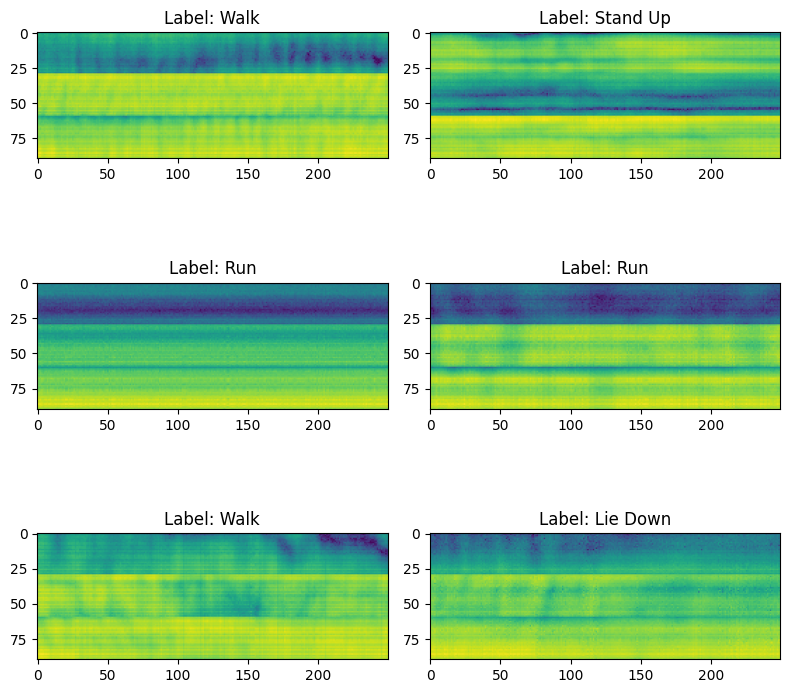

In [6]:
# Check Data
datamodule = UTHARDatamodule(batch_size=BATCH_SIZE)
train_loader = datamodule.train_dataloader()
probe_batch = next(iter(train_loader))

fig, axs = plt.subplots(3,2)
fig.set_size_inches(8,8)
for i in range(6):
    axs[i//2, i%2].imshow(probe_batch[0][i])
    label = probe_batch[1][i].item()
    axs[i//2, i%2].set_title(f"Label: {datamodule.label_names[label]}")

fig.set_tight_layout(True)
plt.show()

## TF-C Pre-training

In [7]:
def tfc_model_cnn():
    # Simpler model than basic CPC CNN
    return TFC_Model(
        input_channels=90,
        TS_length=250,
        single_encoding_size=128,
        pred_head=False,
        batch_size=BATCH_SIZE,
    )
    
def tfc_model_imu():
    time_enc = IMUTransformerEncoder(input_shape=(90, 250), transformer_dim=128, nhead=8, num_encoder_layers=8, dim_feedforward=128, return_cls_token=True)
    freq_enc = IMUTransformerEncoder(input_shape=(90, 250), transformer_dim=128, nhead=8, num_encoder_layers=8, dim_feedforward=128, return_cls_token=True)

    return TFC_Model(
        input_channels=90,
        TS_length=250,
        single_encoding_size=128,
        pred_head=False,
        batch_size=BATCH_SIZE,
        time_encoder=time_enc,
        frequency_encoder=freq_enc,
        learning_rate=1e-4,
    )

### IMU Transformer Pretrain

In [9]:
imu_model = tfc_model_imu()
trainer = Trainer(max_epochs=N_EPOCHS,
                  log_every_n_steps=10,
                  callbacks=[ModelCheckpoint(save_weights_only=True, save_last="link")],
                  logger=TensorBoardLogger(save_dir=LOG_DIR, name='tfc_imu', version='pretrain')
                 )
trainer.fit(imu_model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce MX570 A') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type            | Params | Mode 
-----------------------------------------------------
0 | backbone | TFC_Backbone    | 671 K  | train
1 | loss_fn  | NTXentLoss_poly | 0      | train
-----------------------------------------------------
671 K     Trainable params
0         Non-trainable params
671 K     Total params
2.686     Total estimated model params size (MB)
205       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                  | 0/? [00:00<?, ?it/s]

Loading from ./data/UT-HAR/data/X_val.csv / ./data/UT-HAR/label/y_val.csv
Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


Training: |                         | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


### CNN Pretrain

In [30]:
cnn_model = tfc_model_cnn()
trainer = Trainer(max_epochs=N_EPOCHS,
                  log_every_n_steps=10,
                  callbacks=[ModelCheckpoint(save_weights_only=True, save_last="link")],
                  logger=TensorBoardLogger(save_dir=LOG_DIR, name='tfc_cnn', version='pretrain')
                 )
trainer.fit(cnn_model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type            | Params | Mode 
-----------------------------------------------------
0 | backbone | TFC_Backbone    | 1.2 M  | train
1 | loss_fn  | NTXentLoss_poly | 0      | train
-----------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.756     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                  | 0/? [00:00<?, ?it/s]

Loading from ./data/UT-HAR/data/X_val.csv / ./data/UT-HAR/label/y_val.csv
Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


Training: |                         | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

Validation: |                       | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


## CPC Pre-training

In [8]:
# Model instantiation
def cpc_model_cnn():
    g_enc = Convolutional1DEncoder(input_size=90, kernel_size=3, padding=1)
    g_ar = HARCPCAutoregressive(input_size=128, hidden_size=256, batch_first=True, bidirectional=False)

    return CPC(
        g_enc=g_enc,
        g_ar=g_ar,
        prediction_head_in_channels=256,
        prediction_head_out_channels=128,
        num_steps_prediction=28,
        batch_size=BATCH_SIZE,
        minimum_steps=10,
    )

In [9]:
def cpc_model_imu_transformer():
    g_enc = IMUTransformerEncoder(input_shape=(90, 250), transformer_dim=64, nhead=8, num_encoder_layers=8, dim_feedforward=128)
    g_ar = HARCPCAutoregressive(input_size=64, hidden_size=256, batch_first=True, bidirectional=False)

    return CPC(
        g_enc=g_enc,
        g_ar=g_ar,
        prediction_head_in_channels=256,
        prediction_head_out_channels=64,
        num_steps_prediction=28,
        batch_size=BATCH_SIZE,
        minimum_steps=10,
        learning_rate=1e-4,
    )

### CNN Backbone

In [9]:
# Train backbone CNN
cnn_model = cpc_model_cnn()
trainer = Trainer(max_epochs=N_EPOCHS,
                  log_every_n_steps=10,
                  callbacks=[ModelCheckpoint(save_weights_only=True, save_last="link")],
                  logger=TensorBoardLogger(save_dir=LOG_DIR, name='cpc_cnn', version='pretrain')
                 )
trainer.fit(cnn_model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce MX570 A') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/bruno/miniconda3/envs/mo810/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory ./logs/UT-HAR/cpc_cnn/pretrain/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type                   | Params | Mode 
--------------------------------------------------------------
0 | g_enc      | Convolutional1DEncoder | 39.4 K | train
1 | g_ar       | HARCPCAutoregressive   | 691 K  | train
2 | predictors | ModuleList            

Sanity Checking: |               | 0/? [00:00<?, ?it/s]

Loading from ./data/UT-HAR/data/X_val.csv / ./data/UT-HAR/label/y_val.csv
Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


Training: |                      | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


### IMU Transformer Backbone

In [10]:
# Train backbone IMUTransformer
imu_model = cpc_model_imu_transformer()
trainer = Trainer(max_epochs=N_EPOCHS,
                  log_every_n_steps=10,
                  callbacks=[ModelCheckpoint(save_weights_only=True, save_last="link"), LearningRateMonitor()],
                  logger=TensorBoardLogger(save_dir=LOG_DIR, name='cpc_imu', version='pretrain')
                 )
trainer.fit(imu_model, datamodule)


/home/bruno/miniconda3/envs/mo810/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/bruno/miniconda3/envs/mo810/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory ./logs/UT-HAR/cpc_imu/pretrain/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type                  | Params | Mode 
-------------------------------------------------------------
0 | g_enc      | IMUTransformerEncoder | 302 K  | train
1 | g_ar       | HARCPCAutoregressive  | 642 K  | train
2 | predictors | ModuleList            | 460 K  | train
3 | softmax    | Softmax               | 0     

Sanity Checking: |               | 0/? [00:00<?, ?it/s]

Loading from ./data/UT-HAR/data/X_val.csv / ./data/UT-HAR/label/y_val.csv
Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


Training: |                      | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

Validation: |                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


# Downstream Task Training

In [10]:
FN_EPOCHS = 100
FN_BATCH_SIZE = 64
FN_VERSIONS = 3

In [11]:
def tfc_cnn_backbone(ckpt_file=None):
    if ckpt_file != None:
        pretext_model = TFC_Model.load_from_checkpoint(
            ckpt_file,
            input_channels=90,
            TS_length=250,
            single_encoding_size=128,
            pred_head=False,
            batch_size=BATCH_SIZE,
        )
    else:
        pretext_model = TFC_Model(
            input_channels=90,
            TS_length=250,
            single_encoding_size=128,
            pred_head=False,
            batch_size=BATCH_SIZE,
        )

    return pretext_model.backbone
    
def tfc_imu_backbone(ckpt_file=None):
    time_enc = IMUTransformerEncoder(input_shape=(90, 250), transformer_dim=128, nhead=8, num_encoder_layers=8, dim_feedforward=128, only_last=True)
    freq_enc = IMUTransformerEncoder(input_shape=(90, 250), transformer_dim=128, nhead=8, num_encoder_layers=8, dim_feedforward=128, only_last=True)

    if ckpt_file != None:
        pretext_model = TFC_Model.load_from_checkpoint(
            ckpt_file,
            input_channels=90,
            TS_length=250,
            single_encoding_size=128,
            pred_head=False,
            batch_size=BATCH_SIZE,
            time_encoder=time_enc,
            frequency_encoder=freq_enc,
        )

    return TFC_Backbone(
            input_channels=90,
            TS_length=250,
            single_encoding_size=128,
            time_encoder=time_enc.to('cpu'), # Send to CPU for projector input size calculation
            frequency_encoder=freq_enc.to('cpu'), # Send to CPU for projector input size calculation
            )

def cpc_imu_backbone(ckpt_file=None):
    g_enc = IMUTransformerEncoder(input_shape=(90, 250), transformer_dim=64, nhead=8, num_encoder_layers=8, dim_feedforward=128)
    g_ar = HARCPCAutoregressive(input_size=64, hidden_size=256, batch_first=True, bidirectional=False)

    if ckpt_file != None:
        pretext_model = CPC.load_from_checkpoint(
            ckpt_file,
            g_enc=g_enc,
            g_ar=g_ar,
            prediction_head_in_channels=256,
            prediction_head_out_channels=64,
            num_steps_prediction=28,
            batch_size=32,
            minimum_steps=10,
        )
        
    return Genc_Gar(g_enc=g_enc, g_ar=g_ar)
    
def cpc_cnn_backbone(ckpt_file=None):
    g_enc = Convolutional1DEncoder(input_size=90, kernel_size=3, padding=1)
    g_ar = HARCPCAutoregressive(input_size=128, hidden_size=256, batch_first=True, bidirectional=False)
    
    if ckpt_file != None:
        pretext_model = CPC.load_from_checkpoint(
            ckpt_file,
            g_enc=g_enc,
            g_ar=g_ar,
            prediction_head_in_channels=256,
            prediction_head_out_channels=128,
            num_steps_prediction=28,
            batch_size=32,
            minimum_steps=10,
        )
        
    return Genc_Gar(g_enc=g_enc, g_ar=g_ar)

def load_backbone(method, name, ckpt_file=None):
    if method == 'cpc':
        if name == 'cnn':
            return cpc_cnn_backbone(ckpt_file)
        elif name == 'imu':
            return cpc_imu_backbone(ckpt_file)
        else:
            raise ValueError(f"Backbone of type '{name}' not recognized")
    elif method == 'tfc':
        if name == 'cnn':
            return tfc_cnn_backbone(ckpt_file)
        elif name == 'imu':
            return tfc_imu_backbone(ckpt_file)
        else:
            raise ValueError(f"Backbone of type '{name}' not recognized")
    else:
        raise ValueError(f"Pretrain method '{method}' not recognized")

In [12]:
models = []

L.seed_everything(4321)
    
for ssl_method in ['cpc', 'tfc']:
    for backbone_model in ['cnn', 'imu']:
        for version in range(FN_VERSIONS):
            for n_samples in [1, 10, 25, 50, 100, 250, 500, 1000]:
                models.append({
                    'init': 'pretrained',
                    'model': backbone_model,
                    'ssl': ssl_method,
                    'version': version,
                    'ckpt_file': f"{LOG_DIR}/{ssl_method}_{backbone_model}/pretrain/checkpoints/last.ckpt",
                    'n_samples': n_samples,
                })
                models.append({
                    'init': 'from_scratch',
                    'model': backbone_model,
                    'ssl': ssl_method,
                    'version': version,
                    'ckpt_file': None,
                    'n_samples': n_samples,
                })

Seed set to 4321


In [ ]:
from timeit import default_timer as timer

n_classes = len(datamodule.label_names)

n_configs_trained = 0
start_time = timer()
for train_info in models:
    backbone = load_backbone(train_info['ssl'], train_info['model'], train_info['ckpt_file'])
    supervised_model = SimpleSupervisedModel(
        backbone=backbone,
        fc=torch.nn.Sequential(
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, n_classes)
        ),
        loss_fn=torch.nn.CrossEntropyLoss(),
        train_metrics={"accuracy": Accuracy("multiclass", num_classes=n_classes, average='macro')},
        val_metrics  ={"accuracy": Accuracy("multiclass", num_classes=n_classes, average='macro')},
        test_metrics ={"accuracy": Accuracy("multiclass", num_classes=n_classes, average='macro')},
    )

    logger = TensorBoardLogger(
        save_dir=LOG_DIR,
        name=f"{train_info['ssl']}_{train_info['model']}/downstream/{train_info['n_samples']}_samples", 
        version=f"{train_info['init']}/v_{train_info['version']}"
    )
    print("-----------------------------")
    print(f"{LOG_DIR}/{train_info['ssl']}_{train_info['model']}/downstream/{train_info['n_samples']}_samples/{train_info['init']}/v_{train_info['version']}")
    print("-----------------------------")

    trainer = Trainer(
        max_epochs=FN_EPOCHS,
        log_every_n_steps=10,
        logger=logger,
        enable_progress_bar=False,
        callbacks=[ModelCheckpoint(monitor='val_accuracy', mode='max', save_top_k=1, save_last=True, save_weights_only=True)]
    )

    trainer.fit(supervised_model, datamodule.train_dataloader(samples_per_class=train_info['n_samples']), datamodule.val_dataloader())

    # Compute and display training statistics
    elapsed = timer() - start_time
    n_configs_trained += 1
    avg = elapsed / n_configs_trained
    print("-----------------------------------")
    print(f"Training stats")
    print(f"  - Avg time to train models: {avg:.2f} seconds ")
    est_total = avg * len(models)
    est_remaining = est_total - elapsed
    print(f"  - Total # models  : {len(models)} model(s)")
    print(f"  - Models trained  : {n_configs_trained} model(s) in {elapsed:.2f} seconds")
    print(f"  - Remaining models: {len(models)-n_configs_trained} model(s). {est_remaining:.2f} s remaining (Estimative)")
    print(f"  - Total time      : {est_total:.2f} seconds (estimate: avg * # models)")